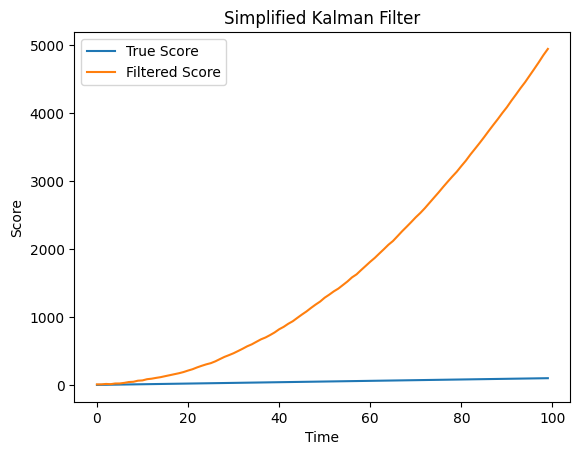

In [2]:
#Kalman Filter
import numpy as np
import matplotlib.pyplot as plt
A=H=1; Q=0.1; R=5
x_est = 0
def kalman(z):
  global x_est
  x_est = A*x_est + H*z
  return x_est
true = np.arange(100)
obs = true + np.random.normal(0,5,len(true))
filt = np.array([kalman(z) for z in obs])
plt.plot(true, label='True Score')
plt.plot(filt, label='Filtered Score')
plt.title('Simplified Kalman Filter')
plt.xlabel('Time')
plt.ylabel('Score')
plt.legend()
plt.show()

In [17]:
!pip install hmmlearn
#HMM
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM
url = "https://raw.githubusercontent.com/natsunoyuki/DataScience/master/gold/gold/gold_price_usd.csv"
df = pd.read_csv(url)
df["datetime"] = pd.to_datetime(df["datetime"])
df["gold_price_usd"] = df["gold_price_usd"].diff()
df = df[df["datetime"] >= "2008-01-01"].dropna()

# Plot original and diff series
plt.figure(figsize=(12, 6))
plt.plot(df["datetime"], df["gold_price_usd"])
plt.title("Daily Gold Price Change")
plt.xlabel("Date")
plt.ylabel("Price Change")
plt.grid()
plt.show()

# HMM Model
X = df[["gold_price_usd"]].values
model = GaussianHMM(n_components=3, covariance_type='diag', n_iter=100,
random_state=42).fit(X)
z = model.predict(X)
print("States:", np.unique(z))
print("Start Prob:", model.startprob_)
print("Transition:", model.transmat_)
print("Means:", model.means_.ravel())
print("Variance:", model.covars_.ravel())

# Plot hidden states
plt.figure(figsize=(12, 6))
for s in np.unique(z):
  m = (z == s)
  plt.plot(df["datetime"][m], df["gold_price_usd"][m], label=f"State {s}") # Added indentation and fixed plotting
plt.title("Gold Price Regimes (HMM States)")
plt.xlabel("Date"); plt.ylabel("Price Change")
plt.legend()
plt.grid()
plt.show()
print("Transition:", model.transmat_)
print("Means:", model.means_.ravel())
print("Variance:", model.covars_.ravel())

HTTPError: HTTP Error 404: Not Found

In [18]:
#Temporal Models
import numpy as np
prior = np.array([0.5, 0.5])
evidence = np.array([[0.9, 0.2], [0.9, 0.2]])
T = np.array([[0.7, 0.3], [0.3, 0.7]])
post = prior
for i, e in enumerate(evidence):
  post = e * (T @ post)
  post /= post.sum()
  post = post.round(3)
  print(f"P(R{i+1}|U1:{i+1}) = {post}")


P(R1|U1:1) = [0.818 0.182]
P(R2|U1:2) = [0.883 0.117]


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 41.6 MB/s eta 0:00:00
Hidden variables: ['TestResult']
Conditional Probability of Disease given evidence:
+-------------------+----------------+
| Disease           |   phi(Disease) |
+===================+================+
| Disease(Healthy)  |         0.4286 |
+-------------------+----------------+
| Disease(Diseased) |         0.5714 |
+-------------------+----------------+
Evidence: {'Symptom1': 'Present', 'Symptom2': 'Present'}


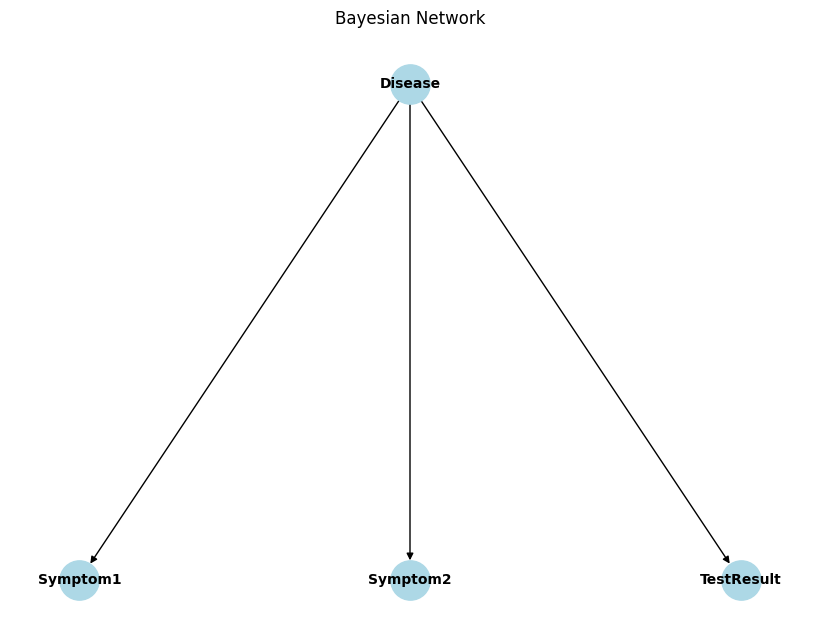

In [24]:
!pip install pgmpy
#Elimination Algorithm
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import networkx as nx, matplotlib.pyplot as plt

# Model
model = DiscreteBayesianNetwork([('Disease','Symptom1'),
('Disease','Symptom2'),
('Disease','TestResult')])
cpd_d = TabularCPD('Disease',2,[[0.9],[0.1]],
state_names={'Disease':['Healthy','Diseased']})
cpd_s1 = TabularCPD('Symptom1',2,[[0.9,0.6],[0.1,0.4]],
evidence=['Disease'],evidence_card=[2],
state_names={'Symptom1':['Absent','Present'],'Disease':['Healthy','Diseased']})
cpd_s2 = TabularCPD('Symptom2',2,[[0.8,0.4],[0.2,0.6]],
evidence=['Disease'],evidence_card=[2],
state_names={'Symptom2':['Absent','Present'],'Disease':['Healthy','Diseased']})
cpd_t = TabularCPD('TestResult',2,[[0.95,0.2],[0.05,0.8]],
evidence=['Disease'],evidence_card=[2],
state_names={'TestResult':['Negative','Positive'],'Disease':['Healthy','Diseased']
})
model.add_cpds(cpd_d, cpd_s1, cpd_s2, cpd_t)
model.check_model()

# Inference
evidence = {'Symptom1':'Present','Symptom2':'Present'}
infer = VariableElimination(model)
result = infer.query(['Disease'], evidence)
print("Hidden variables:", [v for v in model.nodes() if v not in evidence and v!="Disease"])
print("Conditional Probability of Disease given evidence:")
print(result)
print("Evidence:", evidence)

# Plot Network
pos={'Disease':(0.5,0.8),'Symptom1':(0.2,0.2),'Symptom2':(0.5,0.2),'TestResult':(0.8,0.2)}
plt.figure(figsize=(8,6))
nx.draw(model, pos, with_labels=True, node_size=800,
node_color='lightblue', font_size=10, font_weight='bold')
plt.title("Bayesian Network")
plt.show()

In [25]:
#Enumeration Algorithm
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
model = DiscreteBayesianNetwork([
('Disease','Symptom1'),
('Disease','Symptom2'),
('Disease','TestResult')
])
cpd_d =TabularCPD('Disease',2,[[0.1],[0.9]],state_names={'Disease':['Healthy','Diseased']})
cpd_s1 = TabularCPD('Symptom1',2,[[0.9,0.6],[0.1,0.4]],
evidence=['Disease'],evidence_card=[2],
state_names={'Symptom1':['Absent','Present'],'Disease':['Healthy','Diseased']})
cpd_s2 = TabularCPD('Symptom2',2,[[0.8,0.4],[0.2,0.6]],
evidence=['Disease'],evidence_card=[2],
state_names={'Symptom2':['Absent','Present'],'Disease':['Healthy','Diseased']})
cpd_t = TabularCPD('TestResult',2,[[0.9,0.2],[0.1,0.8]],
evidence=['Disease'],evidence_card=[2],
state_names={'TestResult':['Negative','Positive'],'Disease':['Healthy','Diseased']
})
model.add_cpds(cpd_d,cpd_s1,cpd_s2,cpd_t)
model.check_model()
infer = VariableElimination(model)
print("P(Disease | Symptom1=Present, Symptom2=Absent) =")
print(infer.query(['Disease'],{'Symptom1':'Present','Symptom2':'Absent'}))
print("\nP(TestResult | Disease=Diseased) =")
print(infer.query(['TestResult'],{'Disease':'Diseased'}))

P(Disease | Symptom1=Present, Symptom2=Absent) =
+-------------------+----------------+
| Disease           |   phi(Disease) |
+===================+================+
| Disease(Healthy)  |         0.0526 |
+-------------------+----------------+
| Disease(Diseased) |         0.9474 |
+-------------------+----------------+

P(TestResult | Disease=Diseased) =
+----------------------+-------------------+
| TestResult           |   phi(TestResult) |
+======================+===================+
| TestResult(Negative) |            0.2000 |
+----------------------+-------------------+
| TestResult(Positive) |            0.8000 |
+----------------------+-------------------+


Model Valid: True


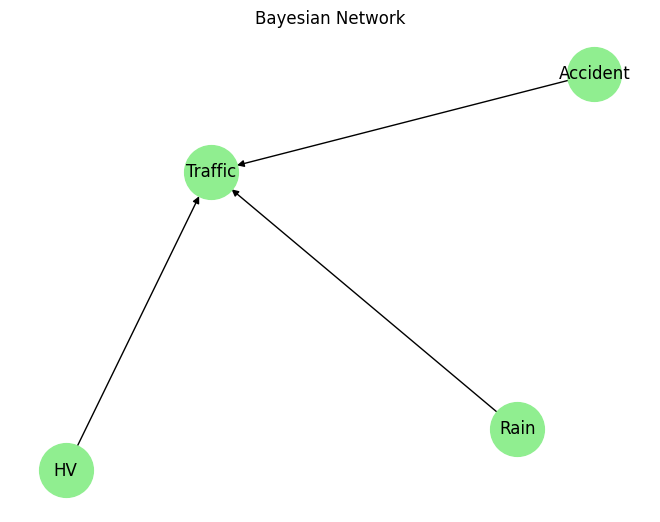


CPDs:
 +---------+-----+
| Rain(0) | 0.2 |
+---------+-----+
| Rain(1) | 0.8 |
+---------+-----+ 
 +-------------+------+
| Accident(0) | 0.95 |
+-------------+------+
| Accident(1) | 0.05 |
+-------------+------+ 
 +-------+------+
| HV(0) | 0.25 |
+-------+------+
| HV(1) | 0.75 |
+-------+------+ 
 +------------+-------------+-----+-------------+-------------+
| Rain       | Rain(0)     | ... | Rain(1)     | Rain(1)     |
+------------+-------------+-----+-------------+-------------+
| Accident   | Accident(0) | ... | Accident(1) | Accident(1) |
+------------+-------------+-----+-------------+-------------+
| HV         | HV(0)       | ... | HV(0)       | HV(1)       |
+------------+-------------+-----+-------------+-------------+
| Traffic(0) | 1.0         | ... | 0.1         | 0.07        |
+------------+-------------+-----+-------------+-------------+
| Traffic(1) | 0.0         | ... | 0.9         | 0.93        |
+------------+-------------+-----+-------------+-------------+

P(

In [26]:
#Bayesian Network
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import networkx as nx
import matplotlib.pyplot as plt
# Bayesian Network Structure
edges = [("Rain","Traffic"), ("Accident","Traffic"), ("HV","Traffic")]
model = DiscreteBayesianNetwork(edges)
# CPDs
cpd_Rain = TabularCPD("Rain", 2, [[0.2],[0.8]])
cpd_Acc = TabularCPD("Accident", 2, [[0.95],[0.05]])
cpd_HV = TabularCPD("HV", 2, [[0.25],[0.75]])
cpd_Traffic = TabularCPD(
"Traffic", 2,
[[1,0.25,0.95,0.9625,0.3,0.4,0.10,0.07],
[0,0.75,0.05,0.0375,0.7,0.6,0.90,0.93]],
evidence=["Rain","Accident","HV"],
evidence_card=[2,2,2]
)
model.add_cpds(cpd_Rain, cpd_Acc, cpd_HV, cpd_Traffic)
print("Model Valid:", model.check_model())
# Plot Network
G = nx.DiGraph()
G.add_edges_from(edges)
nx.draw(G, with_labels=True, node_size=1500, node_color="lightgreen")
plt.title("Bayesian Network")
plt.show()
# Print CPDs
print("\nCPDs:\n", cpd_Rain, "\n", cpd_Acc, "\n", cpd_HV, "\n", cpd_Traffic)
# Inference
infer = VariableElimination(model)
res = infer.query(variables=["Traffic"], evidence={"Rain":1,"Accident":0,"HV":1})
print("\nP(Traffic | Rain=1, Accident=0, HV=1):\n", res)
# Joint Probability
joint_prob = cpd_Rain.values[1] * cpd_Acc.values[0] * cpd_HV.values[1] * res.values[1]
print("\nJoint Probability:", joint_prob)

Probability between 120 and 140 = 0.08738083915827817


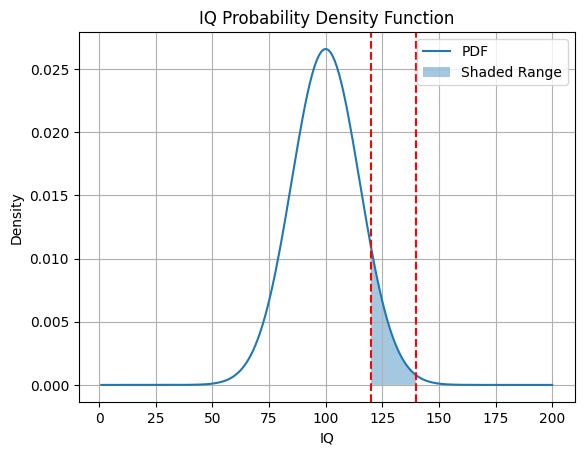

In [27]:
#Noraml Distribution
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.integrate import quad
mean, std = 100, 15
x = np.arange(1, 201)
pdf = norm.pdf(x, mean, std)
low, high = 120, 140
prob, _ = quad(lambda t: norm.pdf(t, mean, std), low, high)
print("Probability between 120 and 140 =", prob)
plt.plot(x, pdf, label="PDF")
plt.fill_between(x, pdf, where=(x>=low)&(x<=high), alpha=0.4, label="Shaded Range")
plt.axvline(low, color='r', linestyle='--')
plt.axvline(high, color='r', linestyle='--')
plt.title("IQ Probability Density Function")
plt.xlabel("IQ"); plt.ylabel("Density")
plt.legend(); plt.grid(); plt.show()

Prior Probability: 21
P(B|A): 34
P(B|¬A): 56
Posterior Probability: -1.7586206896551724
Posterior Percentage: -175.86206896551724 %


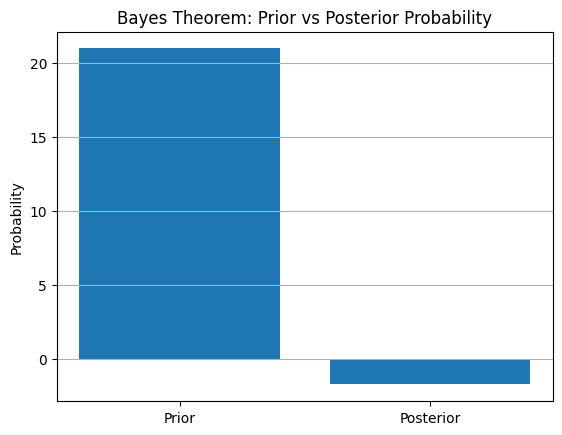

In [29]:
#Bayes Theorem
import matplotlib.pyplot as plt
def bayes(prior, p_b_a, p_b_not_a):
  return (p_b_a * prior) / (p_b_a * prior + p_b_not_a * (1 - prior))
prior = float(input("Prior Probability: "))
p_b_a = float(input("P(B|A): "))
p_b_not_a = float(input("P(B|¬A): "))
posterior = bayes(prior, p_b_a, p_b_not_a)
print("Posterior Probability:", posterior)
print("Posterior Percentage:", posterior * 100, "%")
plt.bar(['Prior', 'Posterior'], [prior, posterior])
plt.title("Bayes Theorem: Prior vs Posterior Probability")
plt.ylabel("Probability")
plt.grid(axis="y")
plt.show()

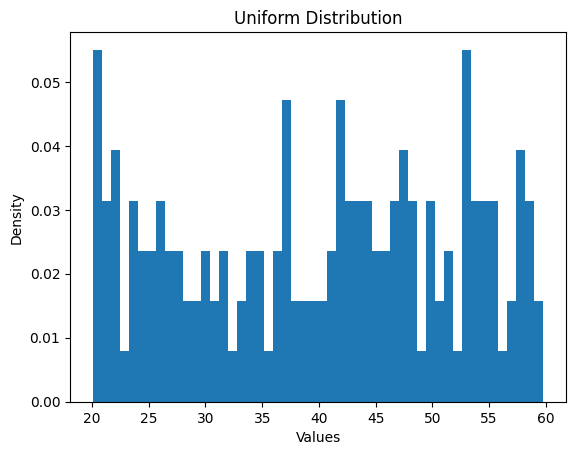

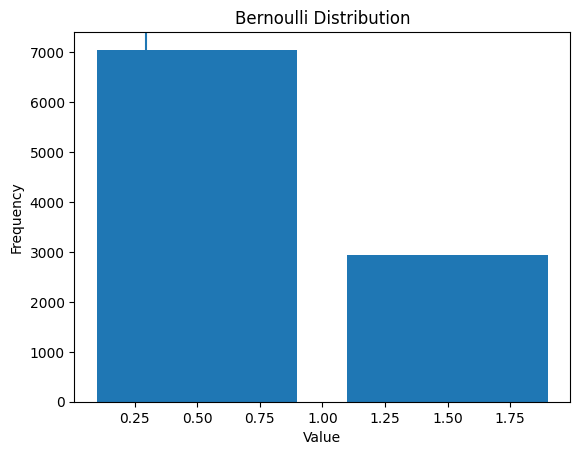

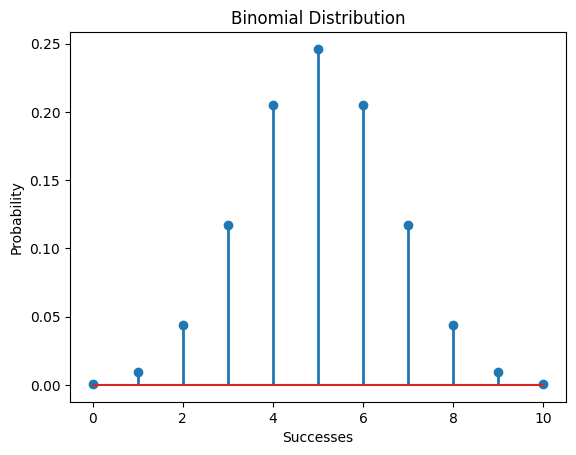

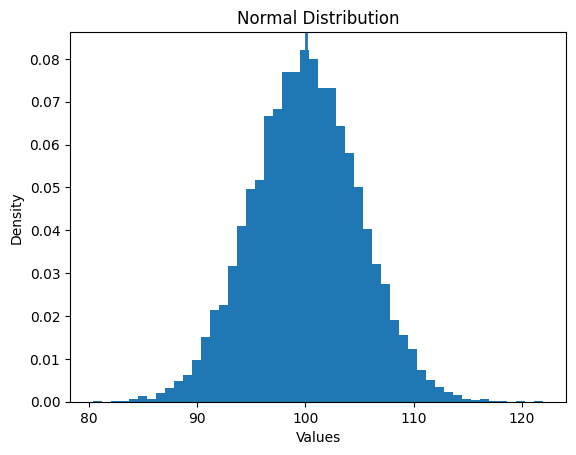

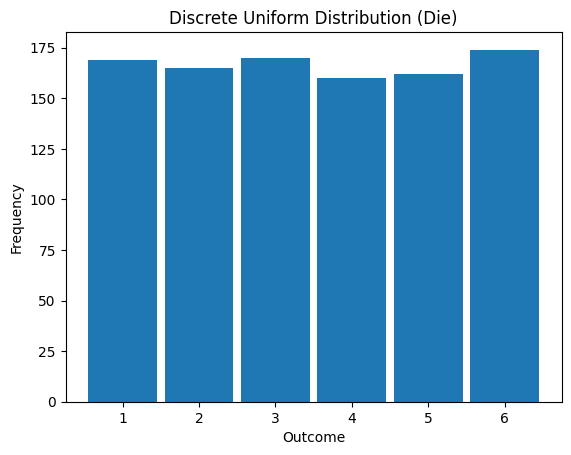

In [30]:
#Probablity
# Uniform
import numpy as np
import matplotlib.pyplot as plt
data = np.random.uniform(20, 60, 160)
plt.hist(data, bins=50, density=True)
plt.title("Uniform Distribution")
plt.xlabel("Values"); plt.ylabel("Density")
plt.show()
#Bernouli
import numpy as np
import matplotlib.pyplot as plt
data = np.random.binomial(1, 0.3, 10000)
plt.hist(data, bins=[0,1,2], rwidth=0.8)
plt.axvline(data.mean())
plt.title("Bernoulli Distribution")
plt.xlabel("Value"); plt.ylabel("Frequency")
plt.show()
#Binomial
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
n, p = 10, 0.5
x = np.arange(n + 1)
pmf = binom.pmf(x, n, p)
markerline, stemlines, baseline = plt.stem(x, pmf)
plt.setp(stemlines, linewidth=2)
plt.title("Binomial Distribution")
plt.xlabel("Successes"); plt.ylabel("Probability")
plt.show()
#Normal
import numpy as np
import matplotlib.pyplot as plt
data = np.random.normal(100, 5, 10000)
plt.hist(data, bins=50, density=True)
plt.axvline(data.mean(), linewidth=2)
plt.title("Normal Distribution")
plt.xlabel("Values"); plt.ylabel("Density")
plt.show()
#Discrete Uniform
import numpy as np
import matplotlib.pyplot as plt
data = np.random.randint(1, 7, 1000)
plt.hist(data, bins=np.arange(1,8)-0.5, rwidth=0.9)
plt.title("Discrete Uniform Distribution (Die)")
plt.xlabel("Outcome"); plt.ylabel("Frequency")
plt.show()


In [39]:
#A Star Algorithm
import heapq, math
def astar(start, goal, neighbors, h):
  pq = [(h(start, goal), start)]
  came, g = {}, {start: 0}
  while pq:
     _, cur = heapq.heappop(pq)
     if cur == goal:
      path = []
     while cur in came:
      path.append(cur)
      cur = came[cur]
     return [start] + path[::-1]
for nxt in neighbors(cur):
  ng = g[cur] + 1
  if nxt not in g or ng < g[nxt]:
    g[nxt], came[nxt] = ng, cur
    f = ng + h(nxt, goal)
    heapq.heappush(pq, (f, nxt))
return None
h = lambda a,b: math.hypot(a[0]-b[0], a[1]-b[1]) # Euclidean
nbr = lambda n: [(n[0]+1,n[1]),(n[0]-1,n[1]),(n[0],n[1]+1),(n[0],n[1]-1)]
start, goal = (0,0), (5,5)
print("Shortest path:", astar(start, goal, nbr, h))


NameError: name 'neighbors' is not defined

In [37]:
#Breafth First Search
from collections import defaultdict, deque
class Graph:
 def __init__(self):
  self.g = defaultdict(list)
 def add(self, u, v):
  self.g[u].append(v)
 def bfs(self, start):
  visited = set([start])
  q = deque([start])
  print("BFS from", start, ":", end=" ")
  while q:
   v = q.popleft()
   print(v, end=" ")
   for n in self.g[v]:
     if n not in visited:
       visited.add(n)
       q.append(n)
if __name__ == "__main__":
 g = Graph()
 edges = [(0,1),(0,2),(0,3),(1,4),(2,5),(2,6),(3,7),(3,8),
(5,9),(5,7),(7,10),(7,11)]
 for u,v in edges: g.add(u,v)
 g.bfs(0)

BFS from 0 : 0 1 2 3 4 5 6 7 8 9 10 11 

In [38]:
#Depth First Search
from collections import defaultdict
class Graph:
 def __init__(self):
  self.g = defaultdict(list)
 def add(self, u, v):
  self.g[u].append(v)
 def dfs(self, v, visited=None):
  if visited is None: visited = set()
  visited.add(v)
  print(v, end=' ')
  for n in self.g[v]:
   if n not in visited:
    self.dfs(n, visited)
g = Graph()
edges = [('A','B'), ('A','C'), ('B','Z'), ('B','C'),
('C','D'), ('D','H'), ('D','I'), ('D','A'),
('E','A'), ('E','D')]
for u,v in edges: g.add(u,v)
print("DFS from A:")
g.dfs('A')


DFS from A:
A B Z C D H I 